<h2>Data Analytics- notebook, empty template</h2>

**NOTE:** All AI usage rules etc. apply to data analytics notebooks too. Always mention if generative AI has been used, and how you can be sure the solution is correct!

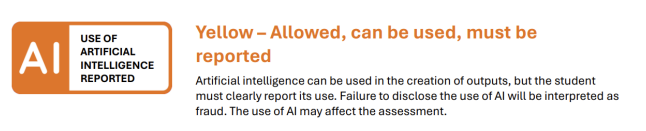

<h4><b>Dataset name / short description:</b></h4>

**Motorcycle Sales Dataset**

This dataset contains information about used motorcycle sales.

The main information includes:
- Motorcycle name
- Selling price
- Year of manufacture
- Seller type
- Owner type
- Kilometres driven
- Ex-showroom price

<h4><b>Data source (url):</b></h4>

Downloaded from the moodle

<h4><b>Data format:</b></h4>

The data is stored in **CSV (Comma-Separated Values)** format.

<h4><b>Data description, features and limitations:</b></h4>

### Important features

- **name** – motorcycle model/name.
- **selling_price** – price at which the motorcycle is sold.
- **year** – manufacturing year.
- **seller_type** – whether the seller is an individual or dealer.
- **owner** – number of previous owners.
- **km_driven** – kilometres driven.
- **ex_showroom_price** – original/ex-showroom price when available.

### Limitations - Used the Help of AI

- `ex_showroom_price` has many missing values, so analyses using this column should only use rows where the value is available.
- The dataset contains many different motorcycle models.
- The number of dealer listings is very small compared with individual listings, so seller-type comparisons should be treated carefully.
- Correlation shows a relationship between variables, but it does not prove causation.
- The data is a sample of motorcycle sales and may not represent every motorcycle sale.

<h3><b>Code: importing modules, custom functions and loading the data</b></h3>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("motorcycle_sales (1).csv")

df.head()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


In [3]:
# Check the missing values and duplicated rows
print(df.isna().sum())

# Duplicated rows
print('Duplicate Rows',df.duplicated().sum())

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64
Duplicate Rows 6


<h3><b>Code: Data clean-up procedure</b></h3>

- There are **435 missing values in `ex_showroom_price`** and **6 duplicate rows**.

- For the basic analysis, we keep the missing `ex_showroom_price` values. When we analyse `ex_showroom_price`, we use only rows where that value is available.

- We also remove duplicate rows.

In [4]:
# Removing duplicate rows
df = df.drop_duplicates().copy()

# Check missing values again
df.isna().sum()


name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    433
dtype: int64


- The duplicate rows were removed using `drop_duplicates()`.
- After removing duplicates, **433 missing values** remain in `ex_showroom_price`.
- For the basic analysis, we keep the missing `ex_showroom_price` values.


<h3><b>Code: Data analysis</b></h3>

#### we look at the average and median motorcycle selling price.

In [5]:
print(df["selling_price"].describe())

print("\nAverage selling price:", df["selling_price"].mean())
print("Median selling price:", df["selling_price"].median())

count      1055.000000
mean      59713.818957
std       56414.384170
min        5000.000000
25%       28000.000000
50%       45000.000000
75%       70000.000000
max      760000.000000
Name: selling_price, dtype: float64

Average selling price: 59713.818957345975
Median selling price: 45000.0


### Result

The average selling price is about **59,638**, while the median is **45,000**.

The difference between the average and median suggests that some expensive motorcycles increase the average price.

## Which motorcycles have the highest selling prices?

In [6]:
top10 = df.nlargest(10, "selling_price")
print(top10[["name", "selling_price", "year", "owner", "km_driven"]])

                                 name  selling_price  year      owner  \
295                   Suzuki GSX S750         760000  2019  1st owner   
134        Harley-Davidson Street Bob         750000  2013  2nd owner   
289    Kawasaki Ninja 650 [2018-2019]         425000  2017  2nd owner   
13                      Yamaha YZF R3         365000  2019  1st owner   
311        Harley-Davidson Street 750         330000  2014  4th owner   
344                        BMW G310GS         300000  2018  1st owner   
860    Kawasaki Ninja 650 [2018-2019]         300000  2011  1st owner   
897                Kawasaki Ninja 300         300000  2016  1st owner   
130  Royal Enfield Continental GT 650         299000  2019  1st owner   
315     Royal Enfield Interceptor 650         285000  2019  1st owner   

     km_driven  
295       2800  
134      12000  
289      13600  
13        1127  
311       6500  
344       2500  
860      12000  
897       9800  
130       1500  
315       5500  


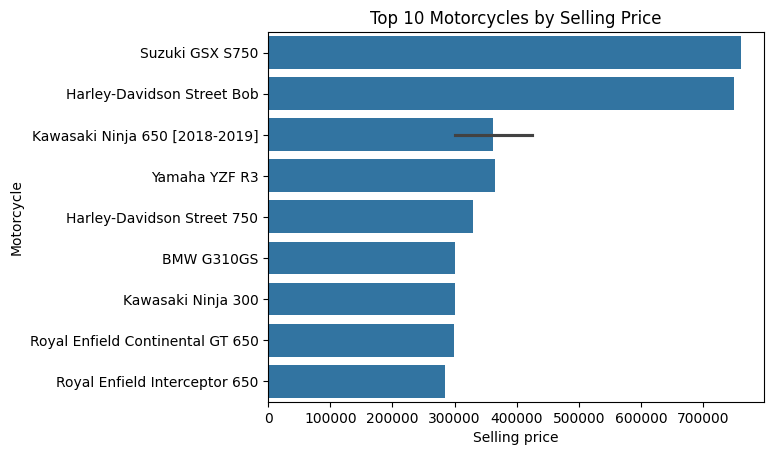

In [7]:
# Visualize it using barplot
sns.barplot(data=top10, x="selling_price", y="name")

plt.title("Top 10 Motorcycles by Selling Price")
plt.xlabel("Selling price")
plt.ylabel("Motorcycle")
plt.show()

### Result

- The highest-priced motorcycle in the dataset is **Suzuki GSX S750**, with a selling price of **760,000**.

- Other high-priced motorcycles include Harley-Davidson, Kawasaki, Yamaha and BMW models.

### Does the manufacturing year affect selling price?

                   year  selling_price
year           1.000000       0.400947
selling_price  0.400947       1.000000


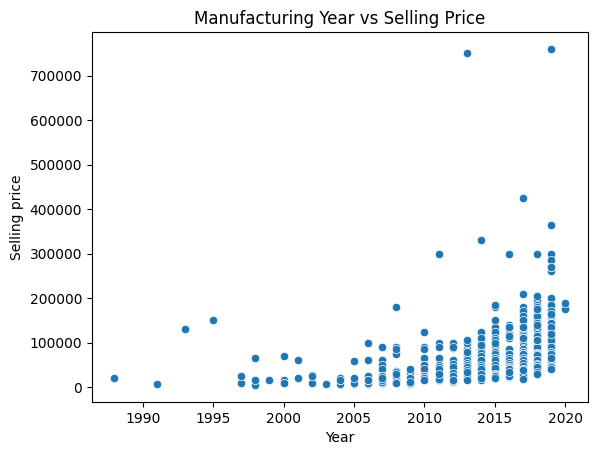

In [8]:
# Check the correlation and visualize it
print(df[["year", "selling_price"]].corr())

# Scatter plot
sns.scatterplot(data=df, x="year", y="selling_price")

plt.title("Manufacturing Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling price")
plt.show()

### Result

The correlation between **year and selling price is about 0.40**.

This is a **moderate positive relationship**. In general, newer motorcycles tend to have higher selling prices, although there are many exceptions.

### Does the number of kilometres driven affect selling price?

- We compare `km_driven` with `selling_price`.

               km_driven  selling_price
km_driven       1.000000      -0.212005
selling_price  -0.212005       1.000000


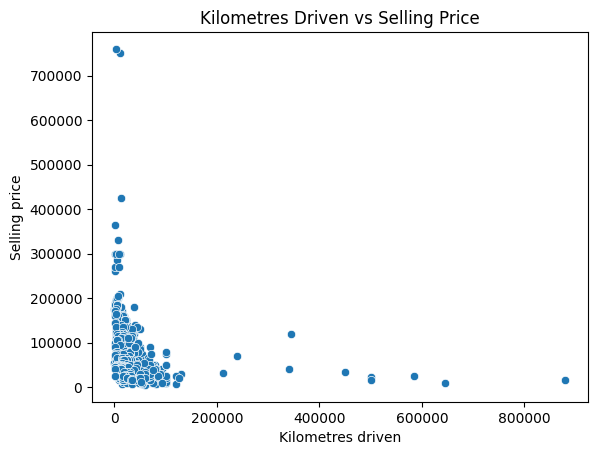

In [9]:
print(df[["km_driven", "selling_price"]].corr())

sns.scatterplot(data=df, x="km_driven", y="selling_price")

plt.title("Kilometres Driven vs Selling Price")
plt.xlabel("Kilometres driven")
plt.ylabel("Selling price")
plt.show()

### Result

- The correlation between **km_driven and selling_price is about -0.21**.

- This is a weak negative relationship. It suggests that motorcycles with more kilometres driven tend to have somewhat lower selling prices, but kilometres driven alone does not explain the price very well.

### Which owner type has the highest average selling price?

- We calculate the average price for each owner category.

In [10]:
owner_prices = (
    df.groupby("owner")["selling_price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

print(owner_prices)

           count           mean   median
owner                                   
4th owner      3  118333.333333  15000.0
1st owner    918   60112.287582  45000.0
3rd owner     11   55727.272727  45000.0
2nd owner    123   55666.658537  32000.0


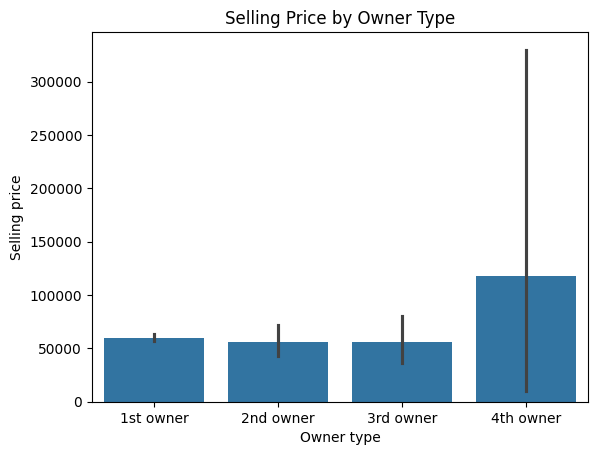

In [11]:
# Visualize it using barplot
sns.barplot(data=df, x="owner", y="selling_price")

plt.title("Selling Price by Owner Type")
plt.xlabel("Owner type")
plt.ylabel("Selling price")
plt.show()

### Result

- The 1st-owner motorcycles make up most of the dataset.

- The 4th-owner group has a high average price, but it contains only **3 motorcycles**, so this average is not reliable enough to make a strong conclusion.

- The 1st-owner group has **924 motorcycles**, with an average selling price of about **60,023**.

#### What variables are related to selling price?

- We can calculate a correlation matrix for the numerical variables.

In [12]:
correlations = df[["selling_price", "year", "km_driven", "ex_showroom_price"]].corr()
print(correlations)

                   selling_price      year  km_driven  ex_showroom_price
selling_price           1.000000  0.400947  -0.212005           0.918659
year                    0.400947  1.000000  -0.287227           0.124832
km_driven              -0.212005 -0.287227   1.000000          -0.120752
ex_showroom_price       0.918659  0.124832  -0.120752           1.000000


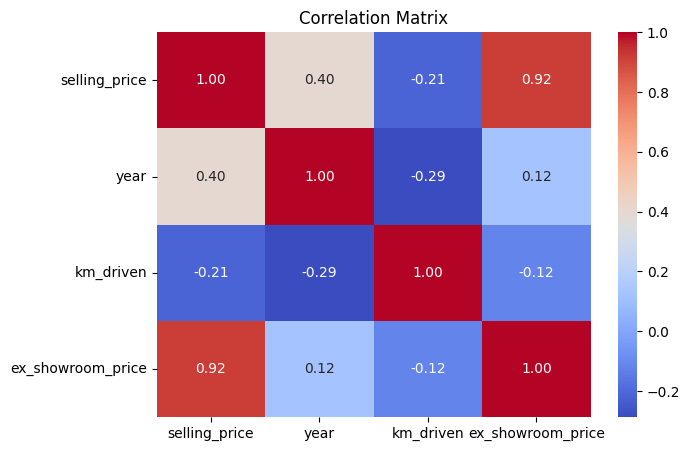

In [13]:
# Visualize using heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(correlations,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Main correlation results

**The strongest relationship with selling price is:**

1. **Ex-showroom price: 0.92** – very strong positive relationship
2. **Year: 0.40** – moderate positive relationship
3. **Km driven: -0.21** – weak negative relationship

**The strong relationship between ex-showroom price and selling price means motorcycles with a higher ex-showroom price generally have a higher used selling price.**

**However, `ex_showroom_price` has many missing values, so this relationship is calculated only for available values.**

### Ex-showroom price vs selling price

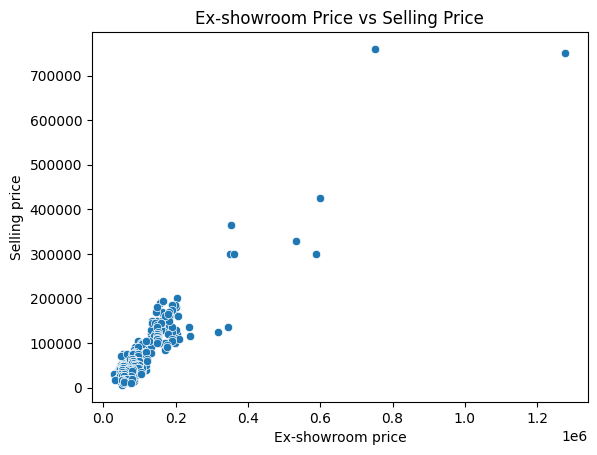

In [14]:
# Keep only rows where ex-showroom price is available
price_data = df.dropna(subset=["ex_showroom_price"])

# Visulaize using scatter-plot
sns.scatterplot(data=price_data,x="ex_showroom_price",y="selling_price")

plt.title("Ex-showroom Price vs Selling Price")
plt.xlabel("Ex-showroom price")
plt.ylabel("Selling price")
plt.show()

### Result

- The scatter plot shows a strong positive relationship between ex-showroom price and selling price.

### Which motorcycle models appear most often?

In [15]:
popular_bikes = df["name"].value_counts().head(10)
print('Popular Bikes:',popular_bikes)

Popular Bikes: name
Bajaj Pulsar 150                 41
Royal Enfield Classic 350        27
Honda Activa [2000-2015]         22
Honda CB Hornet 160R             21
Bajaj Pulsar 180                 20
Royal Enfield Thunderbird 350    19
Hero Honda Splendor Plus         17
Bajaj Discover 125               16
Yamaha FZ S V 2.0                16
Honda Activa 3G                  15
Name: count, dtype: int64


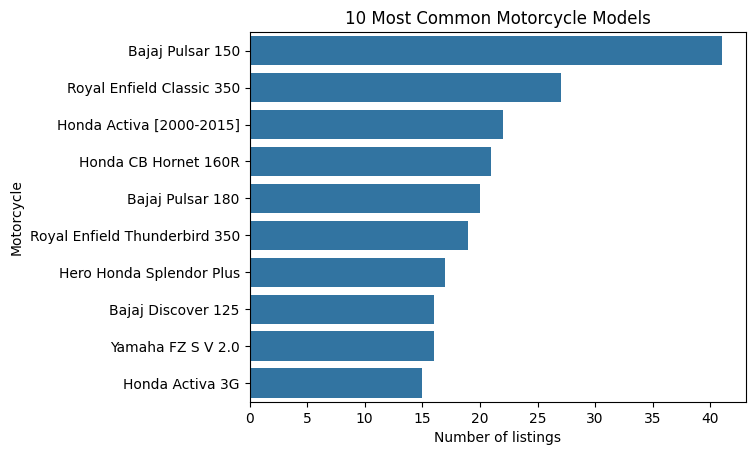

In [16]:
# Visualize it
sns.barplot(x=popular_bikes.values, y=popular_bikes.index)

plt.title("10 Most Common Motorcycle Models")
plt.xlabel("Number of listings")
plt.ylabel("Motorcycle")
plt.show()

### Result

**Bajaj Pulsar 150** is the most common motorcycle model in the dataset, with **41 listings**.

<h3><b>Results and summary:</b></h3>

### Summary

- There are **435 missing values** in `ex_showroom_price`.
- There are **6 duplicate rows**, which are removed before the main analysis.
- The average selling price is about **59,638**, while the median is **45,000**.
- **Suzuki GSX S750** has the highest selling price in the dataset at **760,000**.
- Newer motorcycles generally have higher selling prices. The correlation between year and selling price is about **0.40**.
- Kilometres driven has a weak negative relationship with selling price, with a correlation of about **-0.21**.
- Ex-showroom price has the strongest relationship with selling price, with a correlation of about **0.92**.
- Most motorcycles are **1st-owner** vehicles.
- **Bajaj Pulsar 150** is the most common motorcycle model in the dataset.

Overall, the analysis suggests that **the motorcycle's original/ex-showroom price and manufacturing year are more strongly related to its selling price than the number of kilometres driven**. However, correlation does not prove that one variable causes another.

<h3><b>Ideas for further improvements:</b></h3>

**Used the Help of the AI**
- Analyse the selling price of individual motorcycle brands.
- Create a new `age` column from the manufacturing year and study motorcycle age.
- Investigate unusually expensive or unusually cheap motorcycles as possible outliers.
- Compare selling prices between different owner types using only groups with enough observations.
- Analyse the relationship between selling price and kilometres driven separately for different motorcycle models.
- Use a regression model to predict selling price.
- Fill or otherwise investigate the missing `ex_showroom_price` values if the original values can be obtained.